In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

import joblib
import warnings
warnings.filterwarnings("ignore")
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score



2/ chargement de données

In [ ]:
weather=pd.read_csv("london_weather.csv")
weather.head()

# afficher les noms des colonnes
for col in weather.columns:
    print(col)

date
cloud_cover
sunshine
global_radiation
max_temp
mean_temp
min_temp
precipitation
pressure
snow_depth


3/Inspectez le dataset
 - Nombre de lignes et de colonnes Types de colonnes
- Valeurs manquantes
- Distribution des variables cibles

In [ ]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15341 entries, 0 to 15340
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              15341 non-null  int64  
 1   cloud_cover       15322 non-null  float64
 2   sunshine          15341 non-null  float64
 3   global_radiation  15322 non-null  float64
 4   max_temp          15335 non-null  float64
 5   mean_temp         15305 non-null  float64
 6   min_temp          15339 non-null  float64
 7   precipitation     15335 non-null  float64
 8   pressure          15337 non-null  float64
 9   snow_depth        13900 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 1.2 MB


In [ ]:
#shape
print("rows:",weather.shape[0])
print("columns:",weather.shape[1])

rows: 15341
columns: 10


In [ ]:
#valeurs manquantes
vm=weather.isnull().sum().sort_values(ascending=False)
vm


,0
snow_depth,1441
mean_temp,36
global_radiation,19
cloud_cover,19
precipitation,6
max_temp,6
pressure,4
min_temp,2
date,0
sunshine,0


In [ ]:
# distrubition target
weather["mean_temp"].value_counts()

,count
mean_temp,
10.8,141
10.2,135
8.0,134
15.0,133
16.6,132
...,...
27.0,1
-4.6,1
-5.4,1


4/Nettoyage des données


In [ ]:

#supprimer les lignes dupliquées
weather.drop_duplicates()
#Ne gardez que les rangées où la cible ne manque pas
weather=weather.dropna(subset=["mean_temp"])
#vérifier le resultat
weather.shape

(15305, 10)

5/Analyse exploratoire des données

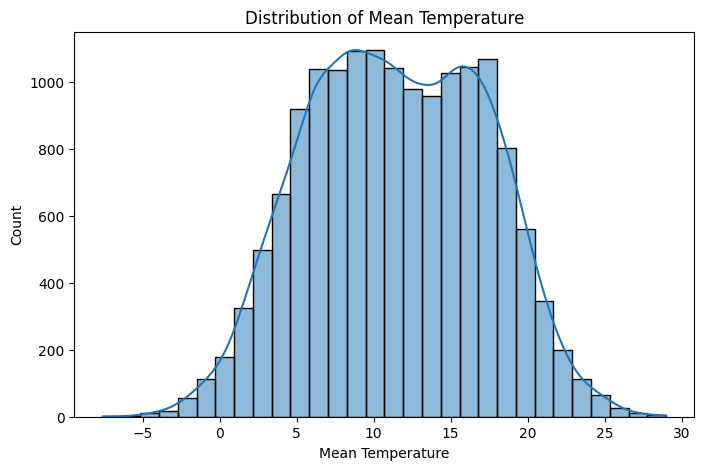

In [ ]:
#Distribution temperature moyenne
plt.figure(figsize=(8,5))
sns.histplot(weather["mean_temp"], bins=30, kde=True)
plt.title("Distribution of Mean Temperature")
plt.xlabel("Mean Temperature")
plt.ylabel("Count")
plt.show()

6/ feature engeneering


In [ ]:
# Convertir date
weather["date"] = pd.to_datetime(weather["date"])

# Créer nouveaux date features
weather["year"] = weather["date"].dt.year
weather["month"] = weather["date"].dt.month
weather["day"] = weather["date"].dt.day
# supprimer la colonne originale
weather = weather.drop("date", axis=1)

weather.head()


,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth,year,month,day
0,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0,1970,1,1
1,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0,1970,1,1
2,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0,1970,1,1
3,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0,1970,1,1
4,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0,1970,1,1


 7/ Correlation matrix


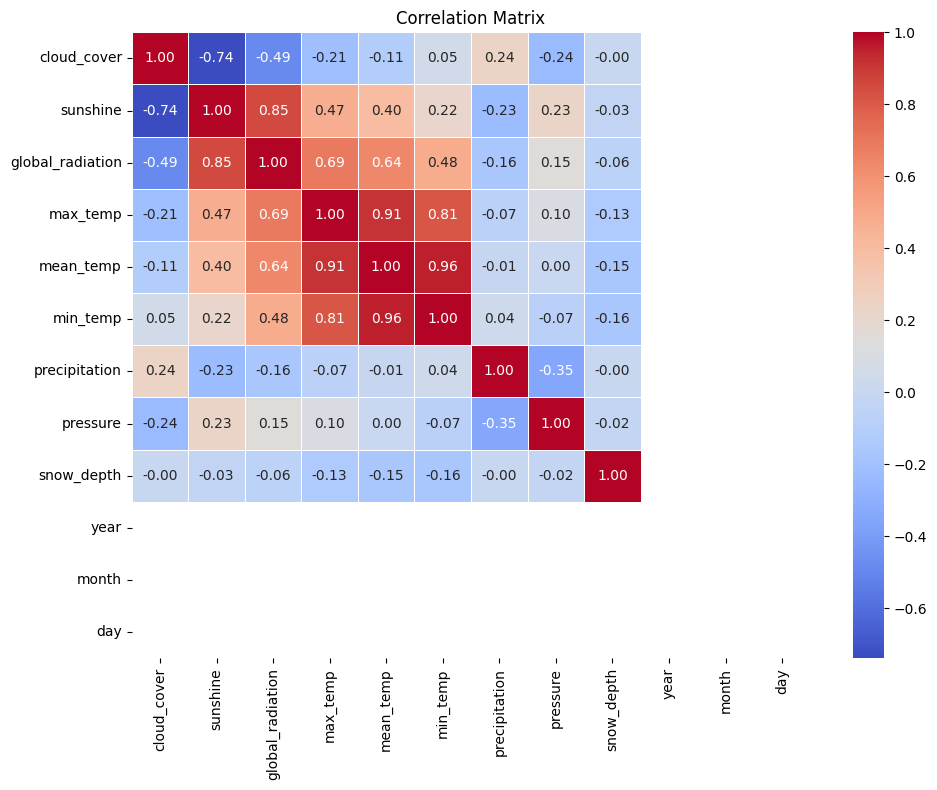

In [ ]:

plt.figure(figsize=(10,8))

sns.heatmap(
    weather.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

8/ Préparation des features



In [ ]:
y = weather["mean_temp"]

X = weather.drop("mean_temp", axis=1)

print("\nFeatures used:")
print(X.columns.tolist())








Features used:
['cloud_cover', 'sunshine', 'global_radiation', 'max_temp', 'min_temp', 'precipitation', 'pressure', 'snow_depth', 'year', 'month', 'day']


/
 Train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

/ Pipeline

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

X = weather.drop("mean_temp", axis=1)

numeric_features = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        )
    ]
)

/10. MLflow experiment

In [ ]:
!pip install mlflow

# Import MLflow
import mlflow
import mlflow.sklearn
print(mlflow.__version__)

mlflow.set_experiment("London_Mean_Temp_Prediction")

3.12.0


2026/05/09 16:39:05 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/09 16:39:05 INFO mlflow.store.db.utils: Updating database tables
2026/05/09 16:39:07 INFO mlflow.tracking.fluent: Experiment with name 'London_Mean_Temp_Prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1778344747691, experiment_id='1', last_update_time=1778344747691, lifecycle_stage='active', name='London_Mean_Temp_Prediction', tags={}, trace_location=None, workspace='default'>

/Définir les modeles


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor


models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )
}

In [ ]:
# 12. Train + evaluate + MLflow

In [ ]:
from sklearn.metrics import mean_squared_error
results = []

best_rmse = np.inf
best_model_name = None
best_pipeline = None

for model_name, model in models.items():

    print(f"\nTraining: {model_name}")

    with mlflow.start_run(run_name=model_name):

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        pipeline.fit(X_train, y_train)

        predictions = pipeline.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, predictions))

        print("RMSE:", round(rmse, 4))

        results.append({
            "Model": model_name,
            "RMSE": rmse
        })

        if rmse < best_rmse:
            best_rmse = rmse
            best_model_name = model_name
            best_pipeline = pipeline

        mlflow.log_param("model_name", model_name)

        for param, value in model.get_params().items():
            mlflow.log_param(param, value)

        mlflow.log_metric("RMSE", rmse)

        mlflow.sklearn.log_model(
            pipeline,
            artifact_path="model"
        )


2026/05/09 16:50:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Training: Linear Regression
RMSE: 0.8737


2026/05/09 16:50:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Training: Random Forest
RMSE: 0.8562


2026/05/09 16:50:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 16:50:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Training: Gradient Boosting
RMSE: 0.8335


2026/05/09 16:51:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 16:51:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


# / Comparer modeles de performance

In [ ]:

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by="RMSE",
    ascending=True
)

print("\n=== Model Comparison ===")
print(results_df)

print("\nBest model:", best_model_name)
print("Best RMSE:", round(best_rmse, 4))


=== Model Comparison ===
               Model      RMSE
2  Gradient Boosting  0.833514
1      Random Forest  0.856250
0  Linear Regression  0.873708

Best model: Gradient Boosting
Best RMSE: 0.8335


/ Récupérer les résultats de l'expérience MLflow

In [ ]:

experiment = mlflow.get_experiment_by_name(
    "London_Mean_Temp_Prediction"
)

experiment_results = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

print("\n=== MLflow Runs ===")
print(experiment_results)


=== MLflow Runs ===
                             run_id experiment_id    status  \
0  8a9d15bdd336492290aee13b67e0bdb6             1  FINISHED   
1  1342dc1c4aa84a499a90a8ad6fa8a46d             1  FINISHED   
2  de63c1062b194a21bc1a12c2fbbe41af             1  FINISHED   
3  e45ec986a8e34eaa84c3dc32c7cf26bc             1    FAILED   
4  71b82d2491b04e2eb1ffbfe08ba012e2             1    FAILED   
5  26956cbb7716426ba8629e9fd2f38e0b             1    FAILED   

                                        artifact_uri  \
0  /content/mlruns/1/8a9d15bdd336492290aee13b67e0...   
1  /content/mlruns/1/1342dc1c4aa84a499a90a8ad6fa8...   
2  /content/mlruns/1/de63c1062b194a21bc1a12c2fbbe...   
3  /content/mlruns/1/e45ec986a8e34eaa84c3dc32c7cf...   
4  /content/mlruns/1/71b82d2491b04e2eb1ffbfe08ba0...   
5  /content/mlruns/1/26956cbb7716426ba8629e9fd2f3...   

                        start_time                         end_time  \
0 2026-05-09 16:51:03.937000+00:00 2026-05-09 16:51:13.147000+00:00   
1 

15. Visualiser les predictions

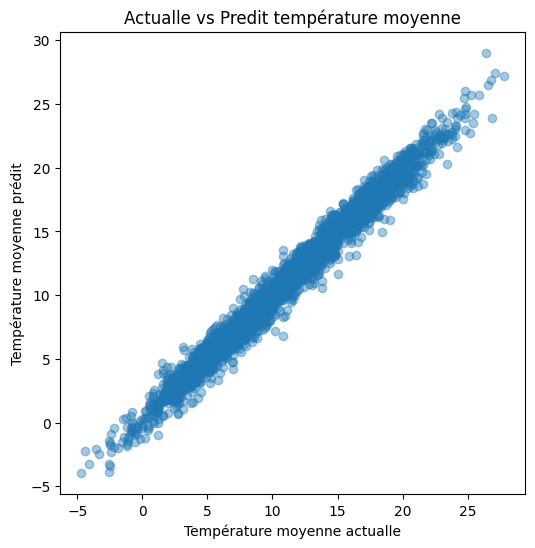

In [ ]:
best_predictions = best_pipeline.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, best_predictions, alpha=0.4)
plt.xlabel("Température moyenne actualle")
plt.ylabel("Température moyenne prédit")
plt.title("Actualle vs Predit température moyenne")
plt.show()

/Testez le modèle de régression sélectionné avec un nouvel exemple

In [ ]:
# ============================================================
# 17. Test the selected Regression model with a new example
# ============================================================

# créer un nouvel exemple météo
new_weather = pd.DataFrame({
    "cloud_cover": [5.0],
    "sunshine": [6.5],
    "global_radiation": [120.0],
    "max_temp": [18.0],
    "min_temp": [9.0],
    "precipitation": [0.2],
    "pressure": [1015.0],
    "snow_depth": [0.0],
    "year": [2025],
    "month": [5],
    "day": [9]
})

# prédire la température moyenne
predicted_temp = best_pipeline.predict(new_weather)

print("Predicted mean temperature:", round(predicted_temp[0], 2), "°C")

Predicted mean temperature: 13.16 °C


/Gardez le modèle pour Flask

In [ ]:
# ============================================================
# 18. garder le modele pour Flask
# ============================================================

import joblib

# Sauvegardez un pipeline complet entraîné
joblib.dump(best_pipeline, "london_weather_model.pkl")

print("Model saved as london_weather_model.pkl")

Model saved as london_weather_model.pkl
